# **LITERATURE REVIEW**


Customer churn analysis has become a key research area in the telecom industry because retaining existing customers is often more cost-effective than acquiring new ones.
Previous studies show that churn is usually influenced by a combination of demographic, service-related, and billing factors.
Among these, **contract type** is one of the strongest predictors, as month-to-month customers are more likely to leave than customers with long-term contracts.
Research also highlights that **monthly charges** can increase churn risk when customers feel the service is too expensive for the value they receive.
Another important factor is **tenure**, because new customers are generally less loyal and more likely to switch providers early.
The type of **internet service**, especially fiber optic connections, has also been linked to higher churn in many studies due to higher pricing or service expectations.
**Payment method** plays a meaningful role too, since automatic payments are often associated with lower churn than manual payment systems.
Studies further suggest that customers using fewer support services such as online security, backup, or tech support may feel less connected to the provider.
Demographic variables like **senior citizen status, partner, and dependents** can also shape customer stability and service continuation.
Overall, the literature suggests that churn is not caused by one single factor, but by a mix of customer profile, billing burden, and service satisfaction.
This makes churn prediction an important business problem for telecom companies aiming to improve retention strategies.
Therefore, analyzing the Telco Customer Churn dataset can help identify the main reasons behind customer departure and support better decision-making.


## **Overview of Dataset Columns for Customer Churn**
The dataset contains customer, service, account, and payment-related columns, making it suitable for Exploratory Data Analysis (EDA). Important features such as tenure, Contract, PaymentMethod, MonthlyCharges, and TotalCharges help identify customer churn patterns. Service-related columns like InternetService, OnlineSecurity, and TechSupport provide insights into customer behavior and service usage. The combination of numerical and categorical variables supports effective data visualization, pattern analysis, and predictive modeling. Overall, the dataset is well-structured for understanding customer retention and churn trends.

## ***churn Determination Factors:***
Factors influencing customer churn are identified through Exploratory Data Analysis (EDA), correlation patterns, and customer behavior analysis. Major factors include contract type, tenure, monthly charges, payment method, internet services, and support-related services. Customers with short tenure, high monthly charges, month-to-month contracts, and lack of online security or tech support show higher churn probability.



| Factor            | Importance / Role         | Impact on Churn                     |
| ----------------- | ------------------------- | ----------------------------------- |
| Contract Type     | Strongest churn indicator | Month-to-month customers churn more |
| Tenure            | Very high importance      | Short tenure = higher churn         |
| Monthly Charges   | High impact               | Higher charges increase churn       |
| Payment Method    | Important billing factor  | Electronic check users churn more   |
| Online Security   | Service-related factor    | No security increases churn         |
| Tech Support      | Customer support factor   | Lack of support raises churn        |
| Internet Service  | Service usage factor      | Fiber optic users show higher churn |
| Paperless Billing | Billing behavior factor   | Paperless users churn slightly more |
| Total Charges     | Moderate impact           | Long-term customers usually stay    |
| Device Protection | Supportive service factor | Protection reduces churn risk       |


In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df=pd.read_csv('telcom_churndataset.csv')
df 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.shape

(7043, 21)

In [5]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df.dropna(inplace=True)

- The TotalCharges column contained some blank values represented as spaces. These values were first converted into missing values, then the column was changed to a numeric data type so it could be properly analyzed. After that, the rows with missing TotalCharges values were removed. This cleaning step made the dataset more consistent and suitable for further analysis.

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

- The TotalCharges column was converted into a numeric format to make it suitable for analysis.

In [8]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: "Yes", 0: "No"})

- The SeniorCitizen column was transformed from binary values into meaningful category labels.
Values of 1 were changed to “Yes” and values of 0 were changed to “No.”
This made the data easier to read and understand.
It also improved the clarity of the dataset for analysis and reporting.

In [9]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [10]:
duplicates = df.duplicated().sum()
print("Total duplicate rows:", duplicates)

Total duplicate rows: 0


In [11]:
df.drop('MultipleLines', axis=1, inplace=True)

- The MultipleLines feature provides limited additional information because it is directly dependent on the PhoneService column.
So, we can remove it. Removing this feature helps simplify the dataset and improves data preprocessing efficienc

In [12]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,No,No,No,66,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   object  
 1   gender            7032 non-null   object  
 2   SeniorCitizen     7032 non-null   object  
 3   Partner           7032 non-null   object  
 4   Dependents        7032 non-null   object  
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   object  
 7   InternetService   7032 non-null   object  
 8   OnlineSecurity    7032 non-null   object  
 9   OnlineBackup      7032 non-null   object  
 10  DeviceProtection  7032 non-null   object  
 11  TechSupport       7032 non-null   object  
 12  StreamingTV       7032 non-null   object  
 13  StreamingMovies   7032 non-null   object  
 14  Contract          7032 non-null   object  
 15  PaperlessBilling  7032 non-null   object  
 16  PaymentMethod     7032 non-nu

In [13]:
df.shape

(7032, 20)

# **Univariate Analysis: Understanding Individual Variable Distribution**

## ***Tenure (Months) Distribution***

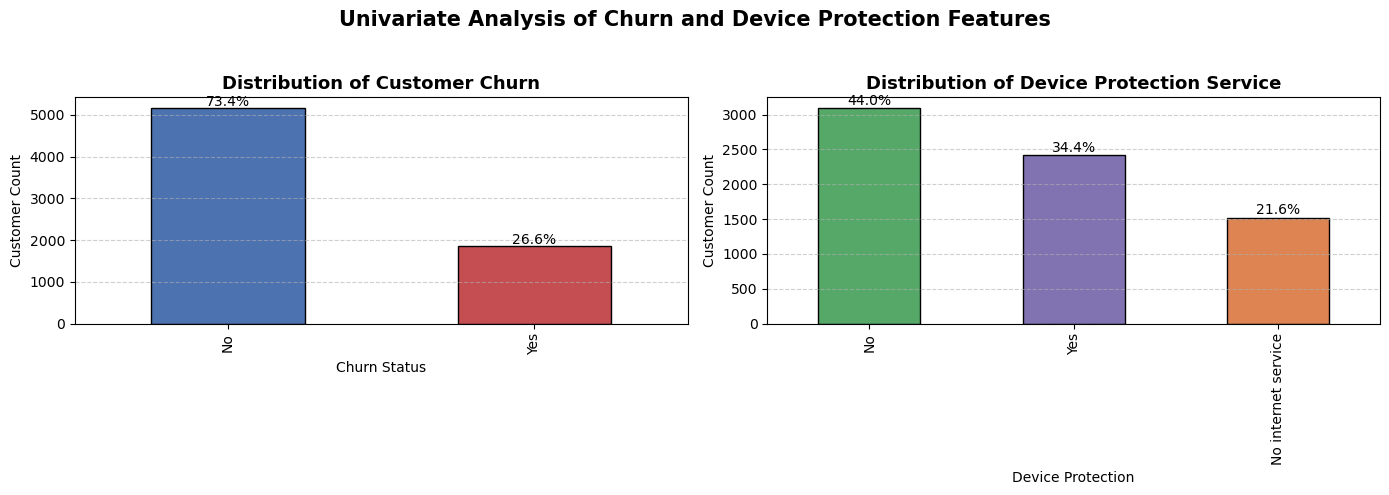

In [14]:

# Value counts
churn_counts = df['Churn'].value_counts()
device_counts = df['DeviceProtection'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 Churn Plot
churn_counts.plot(
    kind='bar',
    color=['#4c72b0', '#c44e52'],
    edgecolor='black',
    ax=axes[0]
)

axes[0].set_title("Distribution of Customer Churn", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Churn Status")
axes[0].set_ylabel("Customer Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Percentage labels for Churn
total1 = churn_counts.sum()
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, f"{(v/total1)*100:.1f}%", 
                 ha='center', fontsize=10)


# 🔹 DeviceProtection Plot
device_counts.plot(
    kind='bar',
    color=['#55a868', '#8172b2', '#dd8452'],
    edgecolor='black',
    ax=axes[1]
)

axes[1].set_title("Distribution of Device Protection Service", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Device Protection")
axes[1].set_ylabel("Customer Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Percentage labels for DeviceProtection
total2 = device_counts.sum()
for i, v in enumerate(device_counts):
    axes[1].text(i, v + 50, f"{(v/total2)*100:.1f}%", 
                 ha='center', fontsize=10)

# Dashboard title
fig.suptitle(
    "Univariate Analysis of Churn and Device Protection Features",
    fontsize=15,
    fontweight='bold'
)

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

- The majority of customers (73.4%) did not churn, while 26.6% customers left the company.
- The churn distribution indicates that customer retention is higher than customer loss.
- In the DeviceProtection feature, 44.0% customers do not use device protection services.
- Around 34.4% customers actively use device protection services.
- About 21.6% customers do not have internet service.
- The dataset shows an imbalance in churn categories, with non-churn customers dominating the data.

 # **Customer Lifetime Value Analysis - Tenure & Charges**

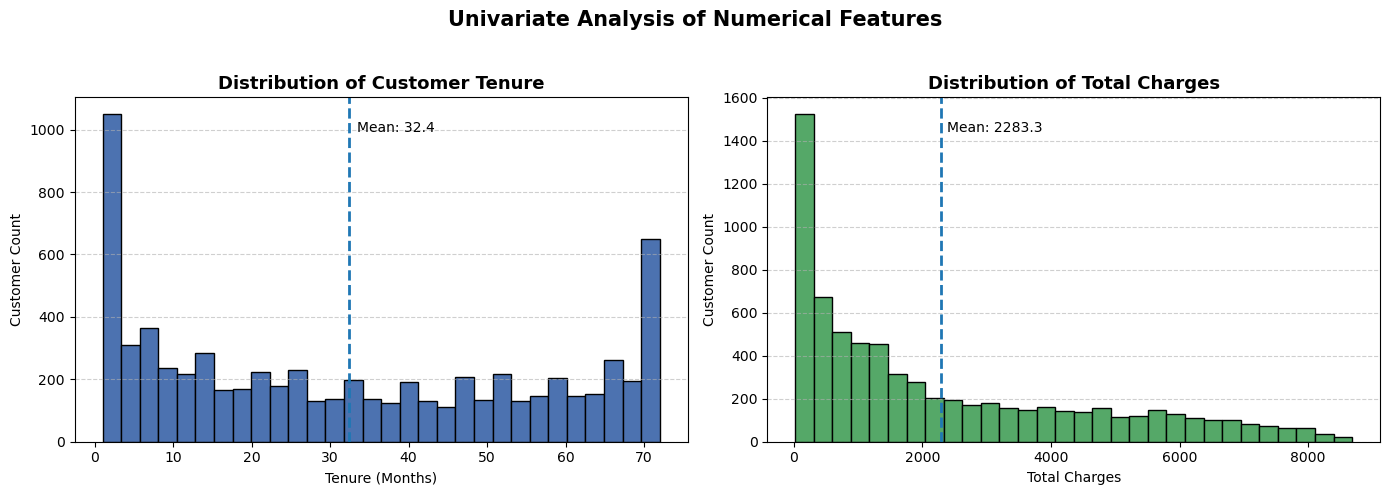

In [15]:

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 Tenure Distribution
axes[0].hist(
    df['tenure'],
    bins=30,
    edgecolor='black',
    color='#4c72b0'
)

axes[0].set_title("Distribution of Customer Tenure", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("Customer Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Add mean line
mean_tenure = df['tenure'].mean()
axes[0].axvline(mean_tenure, linestyle='dashed', linewidth=2)
axes[0].text(mean_tenure + 1, axes[0].get_ylim()[1]*0.9,
             f'Mean: {mean_tenure:.1f}', fontsize=10)


# 🔹 TotalCharges Distribution
axes[1].hist(
    df['TotalCharges'].dropna(),
    bins=30,
    edgecolor='black',
    color='#55a868'
)

axes[1].set_title("Distribution of Total Charges", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Total Charges")
axes[1].set_ylabel("Customer Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Add mean line
mean_charges = df['TotalCharges'].mean()
axes[1].axvline(mean_charges, linestyle='dashed', linewidth=2)
axes[1].text(mean_charges + 100, axes[1].get_ylim()[1]*0.9,
             f'Mean: {mean_charges:.1f}', fontsize=10)

# Dashboard title
fig.suptitle(
    "Univariate Analysis of Numerical Features",
    fontsize=15,
    fontweight='bold'
)

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

- Many customers have either very low or very high tenure values.


- The average customer tenure is around 32.4 months.


- The TotalCharges distribution is positively skewed (right-skewed).


- Most customers have lower total charges, while fewer customers have very high charges.


- The average TotalCharges value is approximately 2283.3.


- Long-term customers tend to contribute more to total revenue.



# **Univariate Analysis of Gender and Monthly Charges**

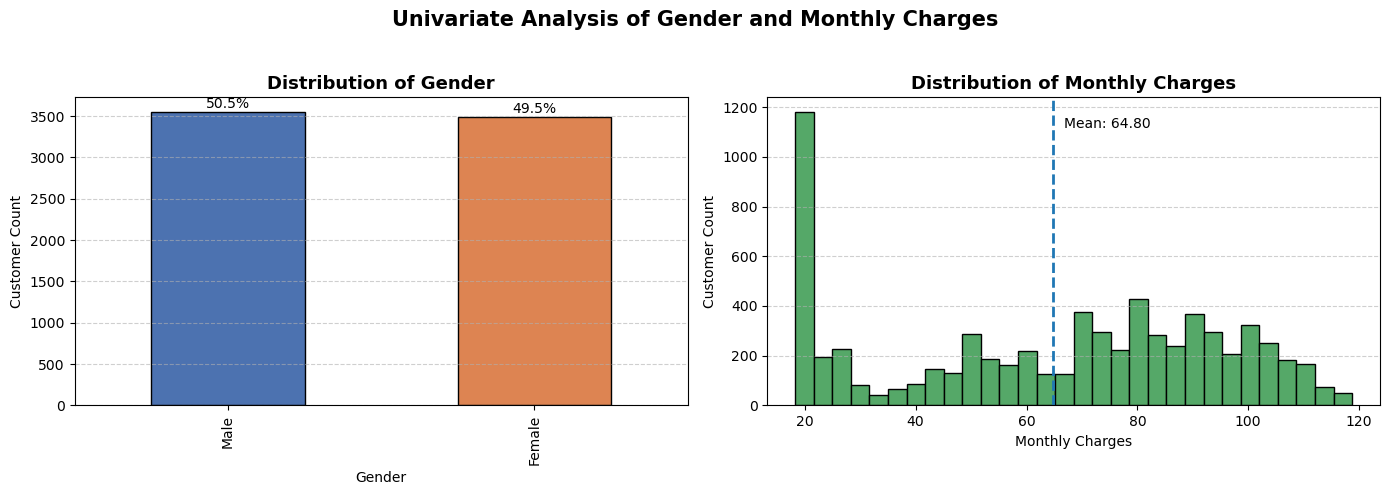

In [16]:


# Data
gender_counts = df['gender'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 Gender Distribution
gender_counts.plot(
    kind='bar',
    color=['#4c72b0', '#dd8452'],
    edgecolor='black',
    ax=axes[0]
)

axes[0].set_title("Distribution of Gender", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Customer Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Percentage labels
total = gender_counts.sum()

for i, v in enumerate(gender_counts):
    axes[0].text(
        i,
        v + 50,
        f"{(v/total)*100:.1f}%",
        ha='center',
        fontsize=10
    )


# 🔹 MonthlyCharges Distribution
axes[1].hist(
    df['MonthlyCharges'],
    bins=30,
    edgecolor='black',
    color='#55a868'
)

axes[1].set_title("Distribution of Monthly Charges", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Monthly Charges")
axes[1].set_ylabel("Customer Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

 # Mean line
mean_monthly = df['MonthlyCharges'].mean()

axes[1].axvline(
    mean_monthly,
    linestyle='dashed',
    linewidth=2
)

# Mean text
axes[1].text(
    mean_monthly + 2,
    axes[1].get_ylim()[1]*0.9,
    f"Mean: {mean_monthly:.2f}",
    fontsize=10
)

# Dashboard title
fig.suptitle(
    "Univariate Analysis of Gender and Monthly Charges",
    fontsize=15,
    fontweight='bold'
)

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

- The gender distribution is almost balanced, with 50.5% male and 49.5% female customers.
- This indicates that the dataset does not show significant gender imbalance.
- The MonthlyCharges distribution shows that most customers are concentrated between medium to high monthly charges.
- The average monthly charge is approximately 64.80.
- The histogram indicates variation in customer billing amounts across the dataset.
- Fewer customers are present at extremely low and extremely high monthly charge values.

# **Customer Service Usage and Contract Type Distribution**

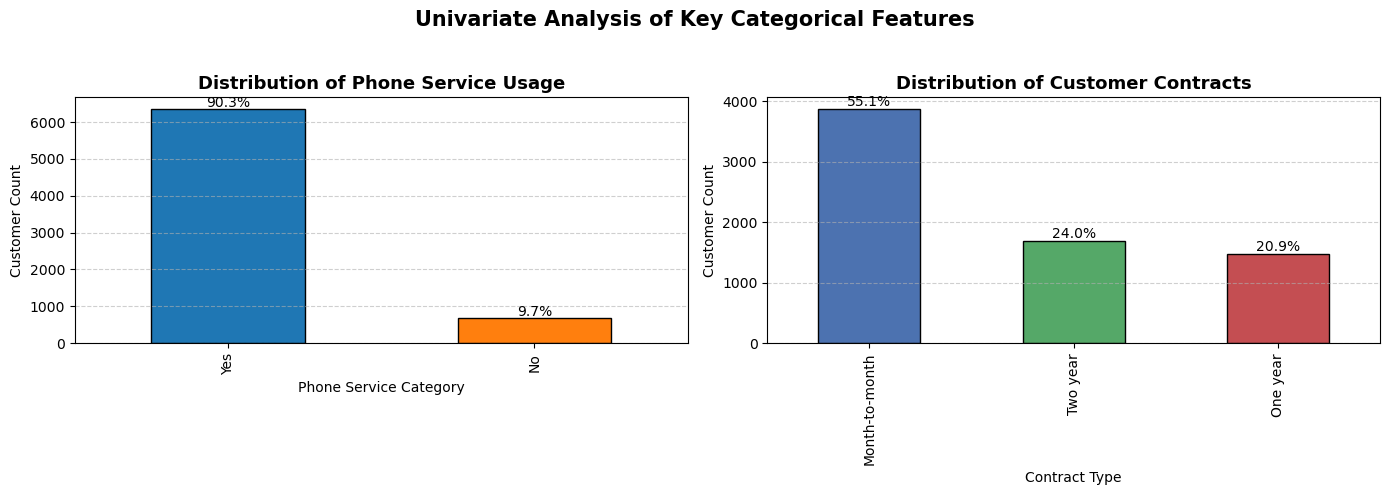

In [17]:

# Data
phone_counts = df['PhoneService'].value_counts()
contract_counts = df['Contract'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 PhoneService Plot
bars1 = phone_counts.plot(
    kind='bar',
    color=['#1f77b4', '#ff7f0e'],
    edgecolor='black',
    ax=axes[0]
)

axes[0].set_title("Distribution of Phone Service Usage", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Phone Service Category")
axes[0].set_ylabel("Customer Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Add % labels
total1 = phone_counts.sum()
for i, v in enumerate(phone_counts):
    axes[0].text(i, v + 50, f"{(v/total1)*100:.1f}%", ha='center', fontsize=10)


# 🔹 Contract Plot
bars2 = contract_counts.plot(
    kind='bar',
    color=['#4c72b0', '#55a868', '#c44e52'],
    edgecolor='black',
    ax=axes[1]
)

axes[1].set_title("Distribution of Customer Contracts", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Contract Type")
axes[1].set_ylabel("Customer Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Add % labels
total2 = contract_counts.sum()
for i, v in enumerate(contract_counts):
    axes[1].text(i, v + 50, f"{(v/total2)*100:.1f}%", ha='center', fontsize=10)


# Global title (dashboard feel)
fig.suptitle("Univariate Analysis of Key Categorical Features", 
             fontsize=15, fontweight='bold')

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

- The analysis shows that most customers (90.3%) are using phone services, while only a small percentage do not use them.
- In contract distribution, month-to-month contracts have the highest share (55.1%), followed by two-year and one-year contracts.
- This indicates that customers prefer flexible plans over long-term commitments.
- Contract type may strongly influence customer churn and retention behavior.

# **Customer Internet Connectivity and Online Security Distribution Analysis**

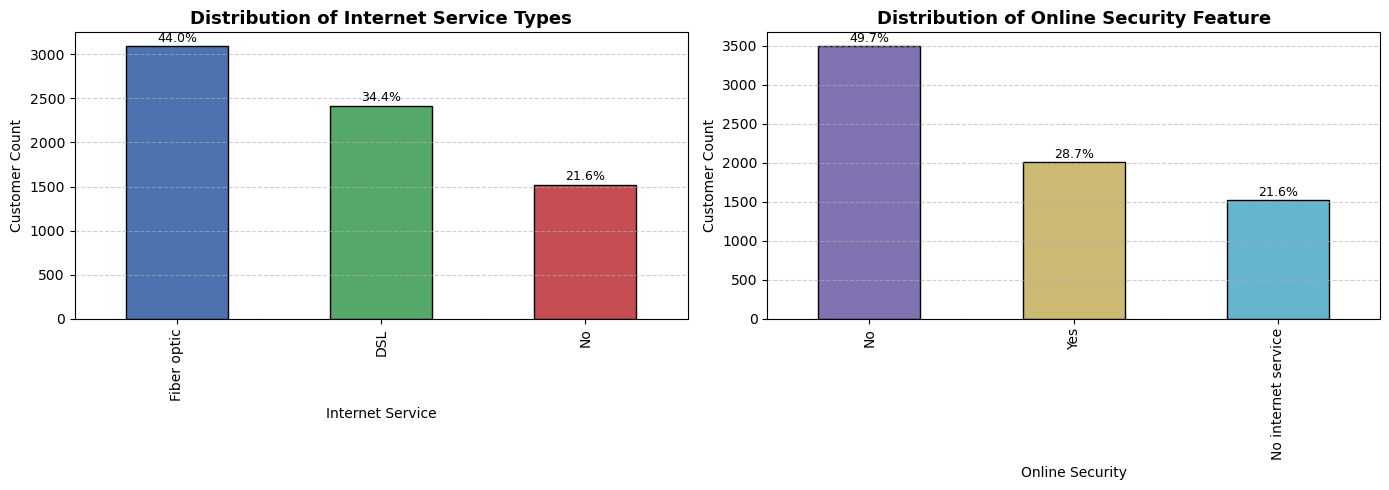

In [18]:

# Value counts
internet_counts = df['InternetService'].value_counts()
security_counts = df['OnlineSecurity'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 InternetService Plot
bars1 = internet_counts.plot(
    kind='bar',
    color=['#4c72b0', '#55a868', '#c44e52'],
    edgecolor='black',
    ax=axes[0]
)

axes[0].set_title("Distribution of Internet Service Types", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Internet Service")
axes[0].set_ylabel("Customer Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Add % labels
total1 = internet_counts.sum()
for i, v in enumerate(internet_counts):
    axes[0].text(i, v + 50, f"{(v/total1)*100:.1f}%", ha='center', fontsize=9)


# 🔹 OnlineSecurity Plot
bars2 = security_counts.plot(
    kind='bar',
    color=['#8172b2', '#ccb974', '#64b5cd'],
    edgecolor='black',
    ax=axes[1]
)

axes[1].set_title("Distribution of Online Security Feature", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Online Security")
axes[1].set_ylabel("Customer Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Add % labels
total2 = security_counts.sum()
for i, v in enumerate(security_counts):
    axes[1].text(i, v + 50, f"{(v/total2)*100:.1f}%", ha='center', fontsize=9)

# Final layout
plt.tight_layout()
plt.show()

### **Distribution of Internet Service Types**
- The graph shows that Fiber optic is the most used internet service with 44.0% customers.
- DSL service is used by around 34.4% customers.
- About 21.6% customers do not use internet services.
- This indicates that high-speed fiber internet is more preferred among customers.

### **Distribution of Online Security Feature**
- Nearly 49.7% customers do not use the online security feature.
- Around 28.7% customers have enabled online security services.
- About 21.6% customers have no internet service, so online security is unavailable to them.
- Customers without online security may be more likely to experience dissatisfaction or churn.

# **Distribution of Tech Support and Streaming TV Features**

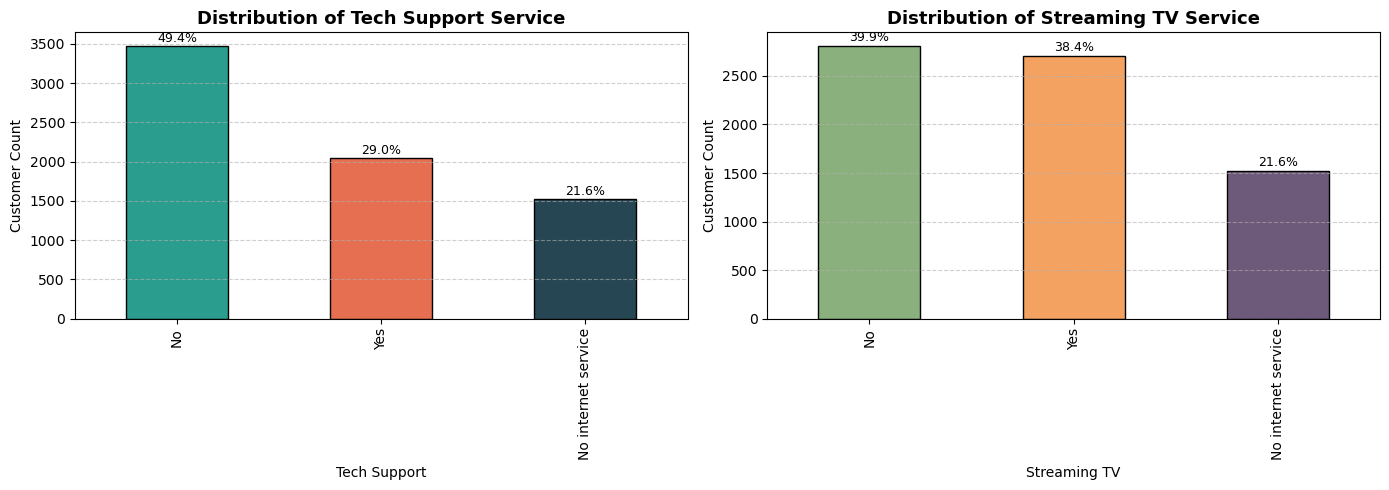

In [19]:
tech_counts = df['TechSupport'].value_counts()
tv_counts = df['StreamingTV'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 TechSupport Plot
tech_counts.plot(
    kind='bar',
    color=['#2a9d8f', '#e76f51', '#264653'],
    edgecolor='black',
    ax=axes[0]
)

axes[0].set_title("Distribution of Tech Support Service", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Tech Support")
axes[0].set_ylabel("Customer Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Add % labels
total1 = tech_counts.sum()
for i, v in enumerate(tech_counts):
    axes[0].text(i, v + 50, f"{(v/total1)*100:.1f}%", ha='center', fontsize=9)


# 🔹 StreamingTV Plot
tv_counts.plot(
    kind='bar',
    color=['#8ab17d', '#f4a261', '#6d597a'],
    edgecolor='black',
    ax=axes[1]
)

axes[1].set_title("Distribution of Streaming TV Service", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Streaming TV")
axes[1].set_ylabel("Customer Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Add % labels
total2 = tv_counts.sum()
for i, v in enumerate(tv_counts):
    axes[1].text(i, v + 50, f"{(v/total2)*100:.1f}%", ha='center', fontsize=9)

# Final layout
plt.tight_layout()
plt.show()

# **Distribution of Tech Support Service**
- The graph shows that around 49.4% customers do not use tech support services.
- About 29.0% customers have subscribed to tech support.
- Nearly 21.6% customers do not have internet service, so tech support is unavailable to them.
- Customers without tech support may face more service-related issues, which can increase churn chances.

# **Distribution of Streaming TV Service**
- Around 39.9% customers do not use streaming TV services.
- Approximately 38.4% customers actively use streaming TV features.
- About 21.6% customers have no internet service.
- The usage of streaming TV services is almost balanced, showing strong customer interest in entertainment services.

## **Partner and Senior Citizen Customer Pattern Analysis**

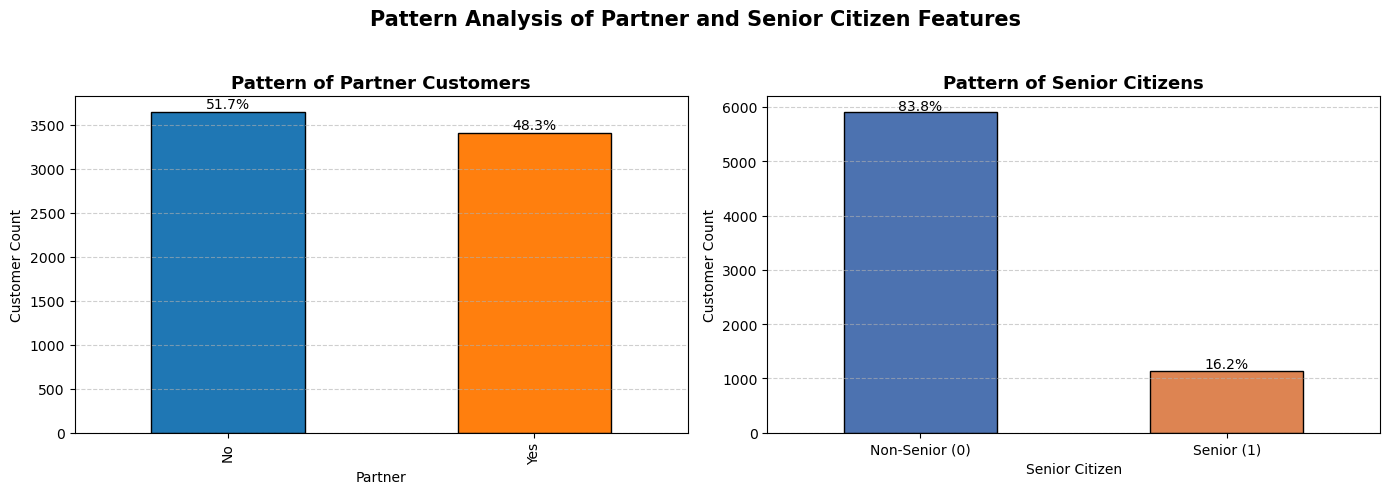

In [46]:

partner_counts = df['Partner'].value_counts()
senior_counts = df['SeniorCitizen'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 Partner Plot
partner_counts.plot(
    kind='bar',
    color=['#1f77b4', '#ff7f0e'],
    edgecolor='black',
    ax=axes[0]
)

axes[0].set_title("Pattern of Partner Customers", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Partner")
axes[0].set_ylabel("Customer Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Percentage labels
total1 = partner_counts.sum()

for i, v in enumerate(partner_counts):
    axes[0].text(i, v + 50, f"{(v/total1)*100:.1f}%", ha='center')

# 🔹 Senior Citizen Plot
senior_counts.plot(
    kind='bar',
    color=['#4c72b0', '#dd8452'],
    edgecolor='black',
    ax=axes[1]
)

axes[1].set_title("Pattern of Senior Citizens", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Senior Citizen")
axes[1].set_ylabel("Customer Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Rename labels
axes[1].set_xticklabels(['Non-Senior (0)', 'Senior (1)'], rotation=0)

# Percentage labels
total2 = senior_counts.sum()

for i, v in enumerate(senior_counts):
    axes[1].text(i, v + 50, f"{(v/total2)*100:.1f}%", ha='center')

# Main Title
fig.suptitle(
    "Pattern Analysis of Partner and Senior Citizen Features",
    fontsize=15,
    fontweight='bold'
)

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()




### **Observed for Partner Customers**
- Customers without partners are slightly higher (51.7%) than customers with partners (48.3%).
- Both categories are almost balanced, showing no major difference in customer distribution.
- The dataset contains a nearly equal proportion of partnered and non-partnered customers.

### **Observed for Senior Citizens**
- Non-senior customers dominate the dataset with 83.8% of total customers.
- Senior citizens represent only 16.2% of the customer base.
- The distribution is highly imbalanced toward non-senior customers.
- Senior citizens form a much smaller segment compared to non-senior users.

# **Customer Billing and Payment System Usage Analysis**

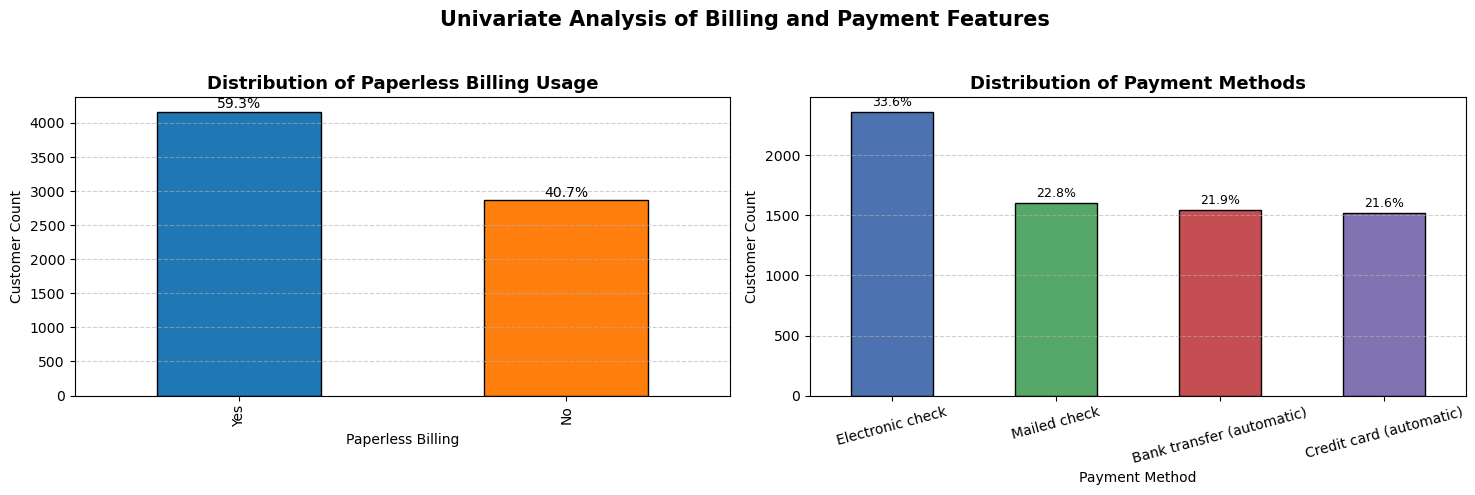

In [20]:

paperless_counts = df['PaperlessBilling'].value_counts()
payment_counts = df['PaymentMethod'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# 🔹 PaperlessBilling Plot
paperless_counts.plot(
    kind='bar',
    color=['#1f77b4', '#ff7f0e'],
    edgecolor='black',
    ax=axes[0]
)

axes[0].set_title("Distribution of Paperless Billing Usage", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Paperless Billing")
axes[0].set_ylabel("Customer Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Add percentage labels
total1 = paperless_counts.sum()
for i, v in enumerate(paperless_counts):
    axes[0].text(i, v + 50, f"{(v/total1)*100:.1f}%", ha='center', fontsize=10)


# 🔹 PaymentMethod Plot
payment_counts.plot(
    kind='bar',
    color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'],
    edgecolor='black',
    ax=axes[1]
)

axes[1].set_title("Distribution of Payment Methods", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Payment Method")
axes[1].set_ylabel("Customer Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Rotate labels for readability
axes[1].tick_params(axis='x', rotation=15)

# Add percentage labels
total2 = payment_counts.sum()
for i, v in enumerate(payment_counts):
    axes[1].text(i, v + 50, f"{(v/total2)*100:.1f}%", ha='center', fontsize=9)

# Global title
fig.suptitle(
    "Univariate Analysis of Billing and Payment Features",
    fontsize=15,
    fontweight='bold'
)

# Final layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

### **Distribution of Paperless Billing Usage**
- The graph shows that around 59.3% customers use paperless billing services.
- About 40.7% customers still prefer traditional billing methods.
- This indicates that most customers prefer digital and convenient payment systems.
- Paperless billing may help improve customer convenience and service efficiency.


### **Distribution of Payment Methods**
- Electronic check is the most commonly used payment method with 33.6% customers.
- Mailed check, bank transfer, and credit card automatic payments have nearly similar usage percentages.
- Automatic payment methods indicate customer preference for convenient and secure transactions.
- Payment method can influence customer satisfaction and may also impact churn behavior.

# ***BIVARIATE ANALYSIS***

## ***Impact of Customer Tenure on Churn Behavior***

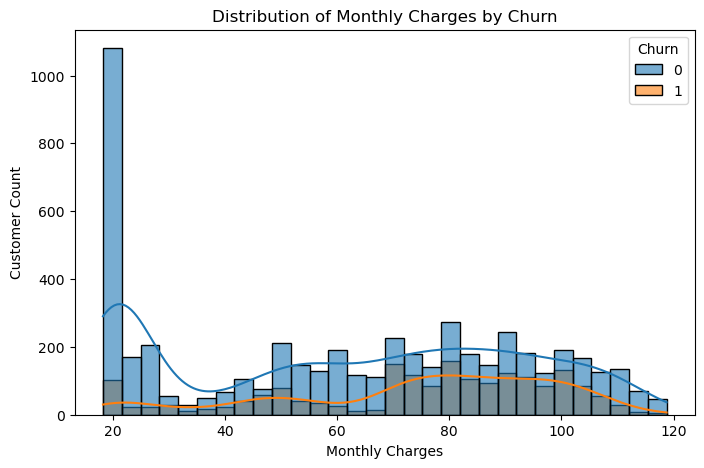


Correlation between Monthly Charges and Churn: nan
Monthly charges have a weak or negative relationship with churn.


In [43]:

# Convert Churn into numeric
df['ChurnNumeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    bins=30,
    kde=True,
    alpha=0.6
)

plt.title('Distribution of Monthly Charges by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')

plt.show()

# Correlation
corr = df['MonthlyCharges'].corr(df['ChurnNumeric'])

print(f"\nCorrelation between Monthly Charges and Churn: {corr:.3f}")



**PATTERN 1 DISCOVERED**:
- Customers with low monthly charges (around 20–30) mostly belong to the non-churn group.
- Churn customers are more concentrated in the higher monthly charges range (70–100).
- The churn distribution increases as monthly charges increase.
- Non-churn customers are distributed across all charge ranges but dominate at lower charges.
- Higher monthly charges appear to increase the probability of customer churn.

Average Tenure:
  Churn     tenure
0    No  37.650010
1   Yes  17.979133


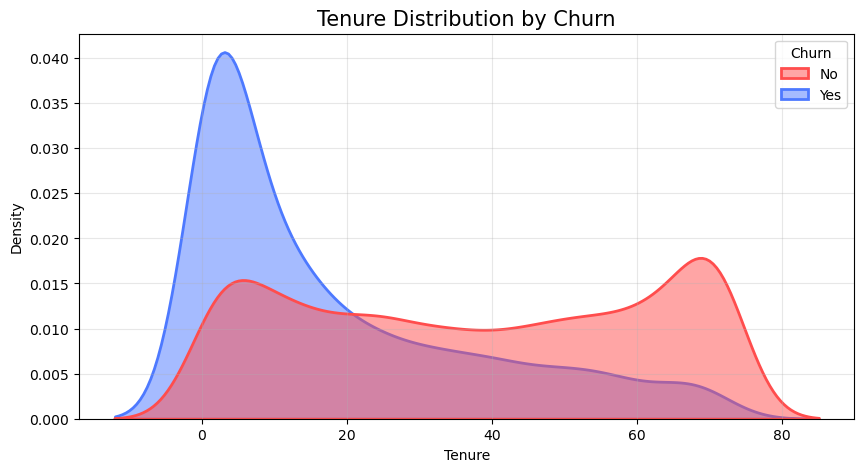

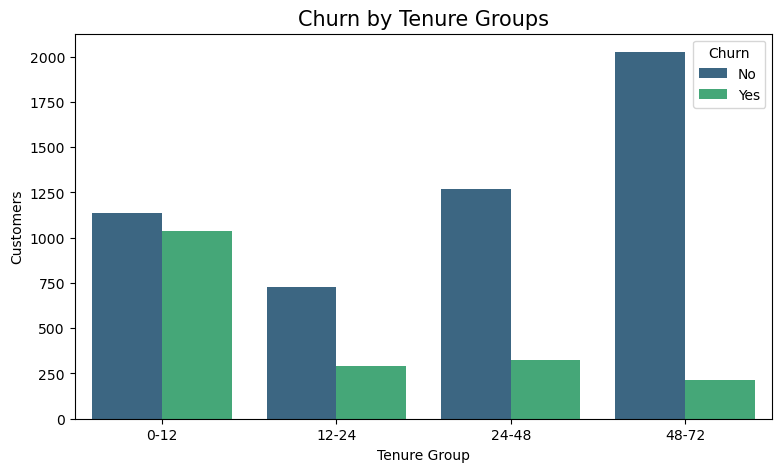


Churn Percentage by Tenure Group:
Churn                No        Yes
tenure_group                      
0-12          52.321839  47.678161
12-24         71.289062  28.710938
24-48         79.611041  20.388959
48-72         90.486824   9.513176


In [21]:


avg_tenure = df.groupby('Churn')['tenure'].mean().reset_index()

print("Average Tenure:")
print(avg_tenure)

# ------------------------------------------
# 2. Better & Simple Distribution Plot
# ------------------------------------------

plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x='tenure',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=['#ff4d4d', '#4d79ff'],
    alpha=0.5,
    linewidth=2
)

plt.title("Tenure Distribution by Churn", fontsize=15)
plt.xlabel("Tenure")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------
# 3. Tenure Group Analysis
# ------------------------------------------

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12','12-24','24-48','48-72']
)

plt.figure(figsize=(9,5))

sns.countplot(
    x='tenure_group',
    hue='Churn',
    data=df,
    palette='viridis'
)

plt.title("Churn by Tenure Groups", fontsize=15)
plt.xlabel("Tenure Group")
plt.ylabel("Customers")

plt.show()

# ------------------------------------------
# 4. Churn Percentage Analysis
# ------------------------------------------

churn_percent = pd.crosstab(
    df['tenure_group'],
    df['Churn'],
    normalize='index'
) * 100

print("\nChurn Percentage by Tenure Group:")
print(churn_percent)

**PATTERN 2 DISCOVERED**:
Customers with 0–12 months tenure show the highest churn concentration, with nearly 45–50% churn rate, while customers with 48–72 months tenure exhibit the lowest churn levels, indicating a strong inverse relationship between tenure and customer retention.

## **Churn Analysis Based on Tech Support Status**

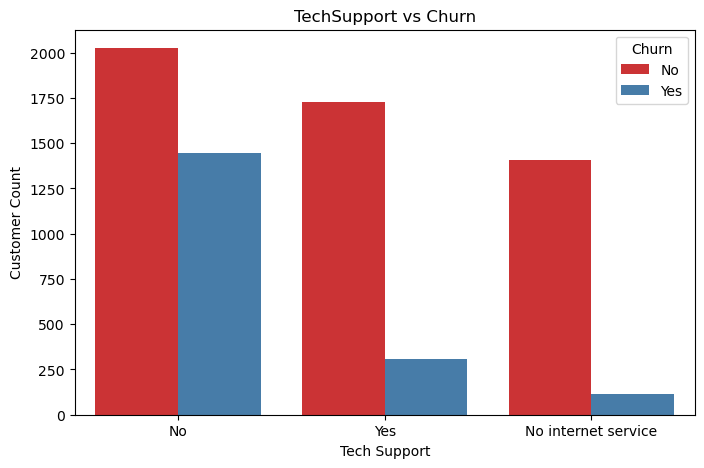

Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078


In [22]:

# Count Graph
plt.figure(figsize=(8,5))

sns.countplot(
    x='TechSupport',
    hue='Churn',
    data=df,
    palette='Set1'
)

plt.title("TechSupport vs Churn")
plt.xlabel("Tech Support")
plt.ylabel("Customer Count")

plt.show()

# Churn Percentage
tech_churn = pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

print(tech_churn)



**PATTERN  3 DISCOVERED  :**

Customers without Tech Support show the highest churn, with nearly 1,450 customers leaving the service, while customers using Tech Support have significantly lower churn, around 300 customers only. Customers with Tech Support also show much higher retention, indicating that technical assistance plays a major role in improving customer satisfaction and reducing churn.

## **Online Security and Churn Distribution**

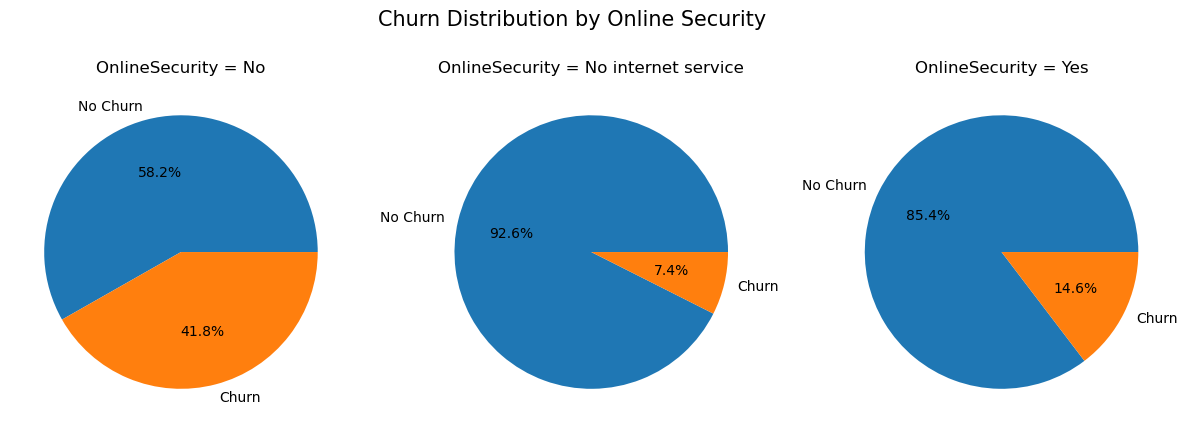

In [23]:
security_churn = pd.crosstab(
    df['OnlineSecurity'],
    df['Churn'],
    normalize='index'
) * 100

# Pie Charts
fig, axes = plt.subplots(1, 3, figsize=(15,5))

categories = security_churn.index

for i, category in enumerate(categories):
    
    axes[i].pie(
        security_churn.loc[category],
        labels=['No Churn', 'Churn'],
        autopct='%1.1f%%'
    )
    
    axes[i].set_title(f'OnlineSecurity = {category}')

plt.suptitle("Churn Distribution by Online Security", fontsize=15)

plt.show()



**PATTERN  5 DISCOVERED :**
- Customers without Online Security show the highest churn rate at nearly 41.8%, while customers with Online Security have a much lower churn rate of only 14.6%. Additionally, customers with no internet service exhibit the lowest churn rate at around 7.4%. This pattern suggests that Online Security services significantly improve customer retention and reduce the likelihood of churn.

# ***Paperless Billing and Customer Churn Analysis***

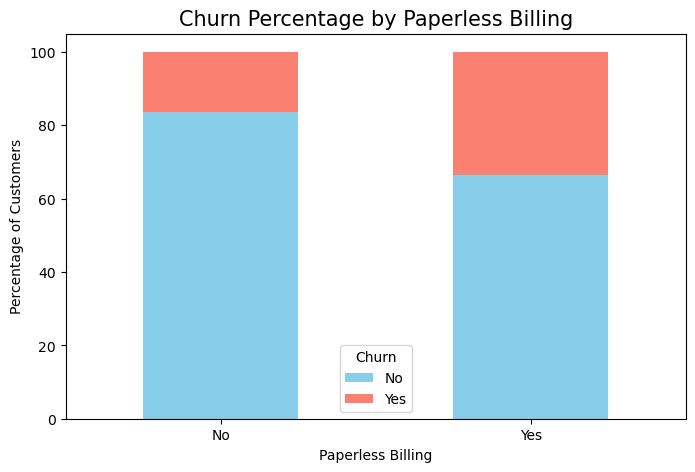

In [24]:

paperless_percent = pd.crosstab(
    df['PaperlessBilling'],
    df['Churn'],
    normalize='index'
) * 100

# Plot
paperless_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=['skyblue', 'salmon']
)

plt.title("Churn Percentage by Paperless Billing", fontsize=15)
plt.xlabel("Paperless Billing")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)

plt.legend(title='Churn')

plt.show()



**PATTERN  6 DISCOVERED :**

Customers using Paperless Billing show a much higher churn rate of around 33–34%, compared to only 16–17% for customers who do not use it. The graph clearly shows that non-paperless customers are more stable, with nearly 83–84% staying with the company. This suggests that customers using paperless billing are relatively more likely to leave the service, making billing method an important churn indicator.

## ***Impact of Payment Methods on Customer Churn Behavior***

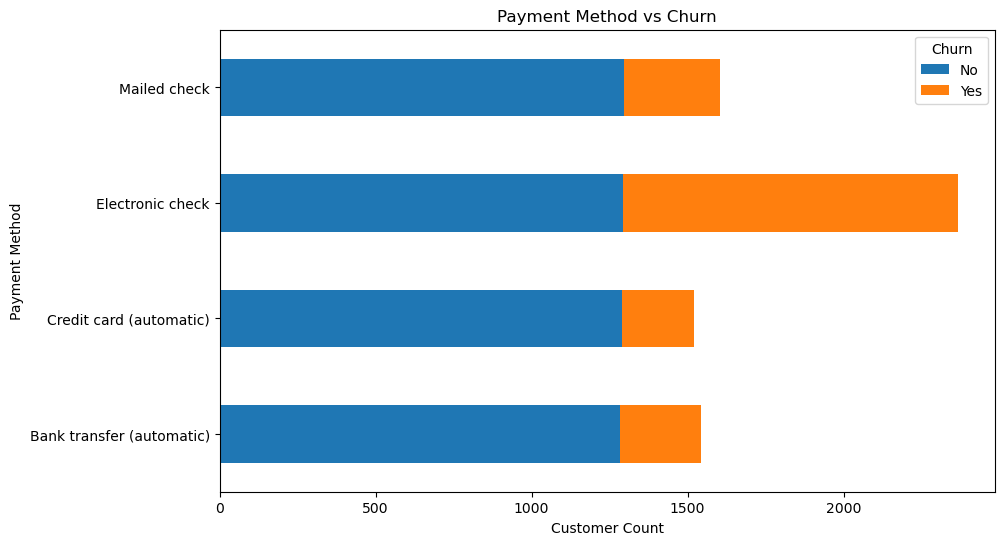

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


In [25]:
# Crosstab
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn']
)

# Horizontal Stacked Bar Chart
payment_churn.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6)
)

plt.title("Payment Method vs Churn")
plt.xlabel("Customer Count")
plt.ylabel("Payment Method")

plt.show()

# Churn Percentage
payment_percent = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

print(payment_percent)



**PATTERN  6 DISCOVERED :**
The graph shows that Electronic Check has the highest churn, with around 1,050 customers leaving the service.
Bank Transfer and Credit Card (automatic) have lower churn, with only about 220–250 churn customers each.
Most payment methods have nearly 1,300 retained customers, showing strong customer retention overall.
Overall, customers using automatic payment methods are less likely to churn compared to manual payment users.

## **Total Charges Churn**

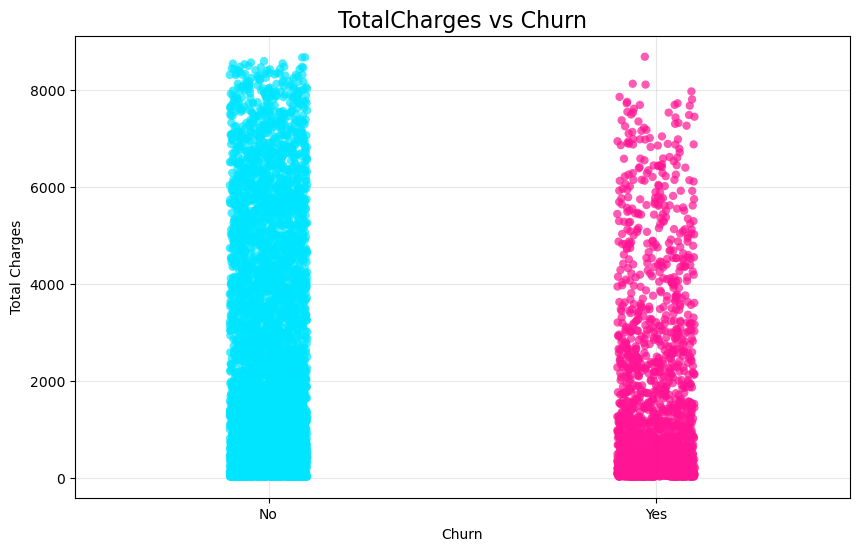

In [33]:
# Strip Plot : TotalCharges vs Churn

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df,
    x='Churn',
    y='TotalCharges',
    hue='Churn',
    palette=['#00E5FF', '#FF1493'],
    size=6,
    alpha=0.7
)

plt.title("TotalCharges vs Churn", fontsize=16)
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.grid(alpha=0.3)

plt.show()

#### **PATTERN 7 DISCOVERED  :**
- Non-churn customers have Total Charges from 0–8500.
- Churn customers are mostly between 0–3000 Total Charges.
- Higher Total Charges customers are less likely to churn.
- Lower Total Charges customers show higher churn behavior.

# Multivariate Analysis

## **Multivariate Analysis of Tenure, Contract Type, and Churn**

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13976\2962430548.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = df.groupby(


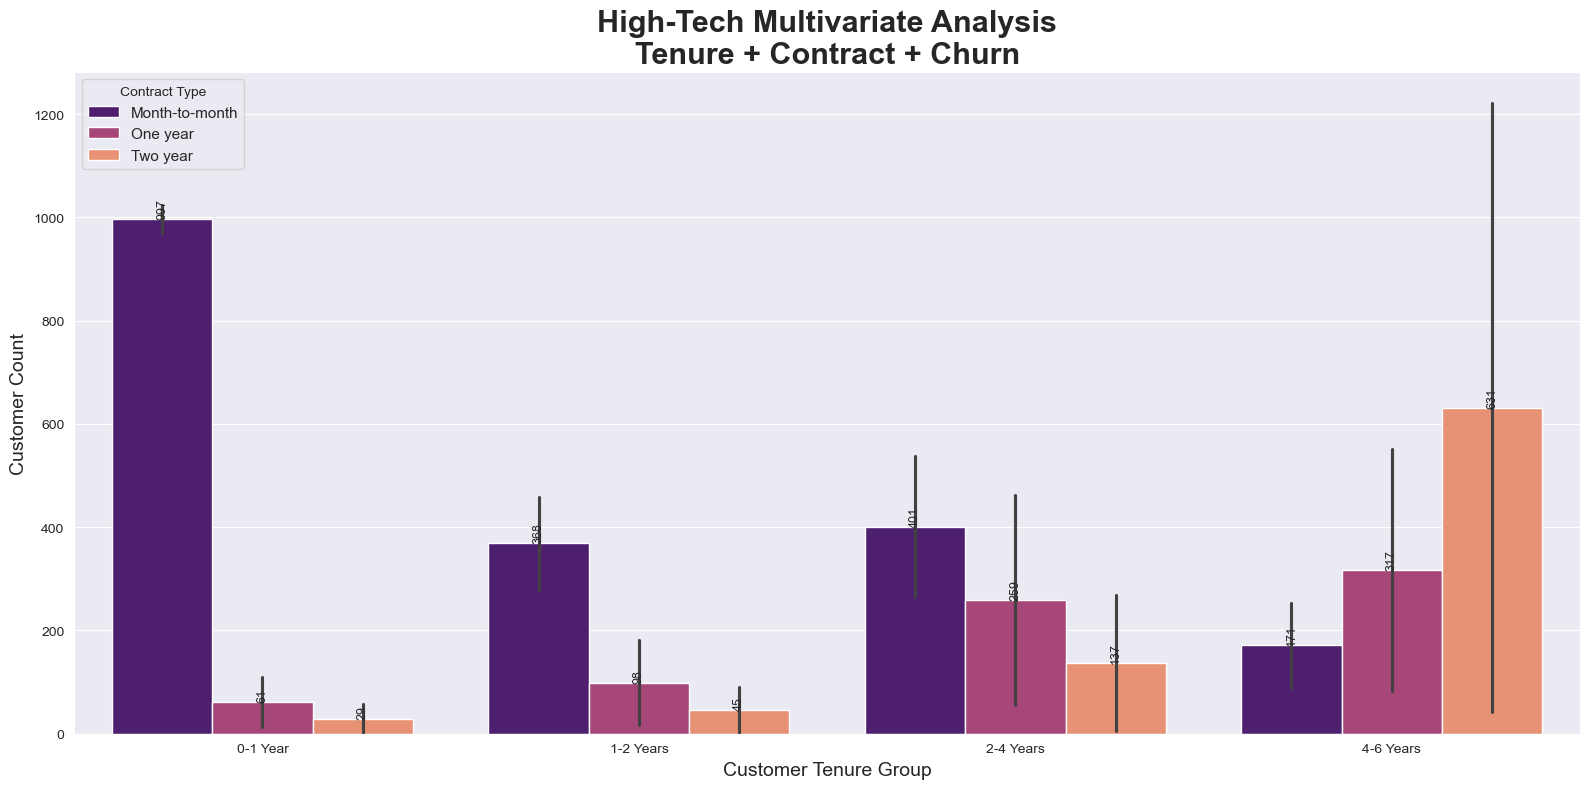

In [3]:
df = pd.read_csv("telcom_churndataset.csv")

# Create Tenure Groups
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=[
        '0-1 Year',
        '1-2 Years',
        '2-4 Years',
        '4-6 Years'
    ]
)

# Create Data
plot_data = df.groupby(
    ['TenureGroup', 'Contract', 'Churn']
).size().reset_index(name='Count')

# Style
sns.set_style("darkgrid")

# Plot
plt.figure(figsize=(16,8))

ax = sns.barplot(
    data=plot_data,
    x='TenureGroup',
    y='Count',
    hue='Contract',
    palette='magma'
)

# Add Churn Labels
for p in ax.patches:
    height = p.get_height()

    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width()/2., height),
            ha='center',
            va='bottom',
            fontsize=9,
            rotation=90
        )

# Title
plt.title(
    'High-Tech Multivariate Analysis\nTenure + Contract + Churn',
    fontsize=22,
    fontweight='bold'
)

# Labels
plt.xlabel(
    'Customer Tenure Group',
    fontsize=14
)

plt.ylabel(
    'Customer Count',
    fontsize=14
)

# Legend
plt.legend(
    title='Contract Type',
    fontsize=11
)

# Tight Layout
plt.tight_layout()

# Show
plt.show()

### **Key Findings**
- Month-to-month contracts are highest in the 0–1 year group, showing new customers prefer flexible plans.
- Short-term contract customers have a higher chance of churn.
- Two-year contracts increase in the 4–6 years group, indicating strong customer loyalty.
- Customer retention improves as tenure increases.
- One-year contract customers show moderate stability.
- Long-term contracts help reduce churn and improve retention.
- The company should encourage customers to shift from month-to-month to long-term plans through discounts and loyalty offers.

# **Contract-Based Churn Behavior by Monthly Spending**

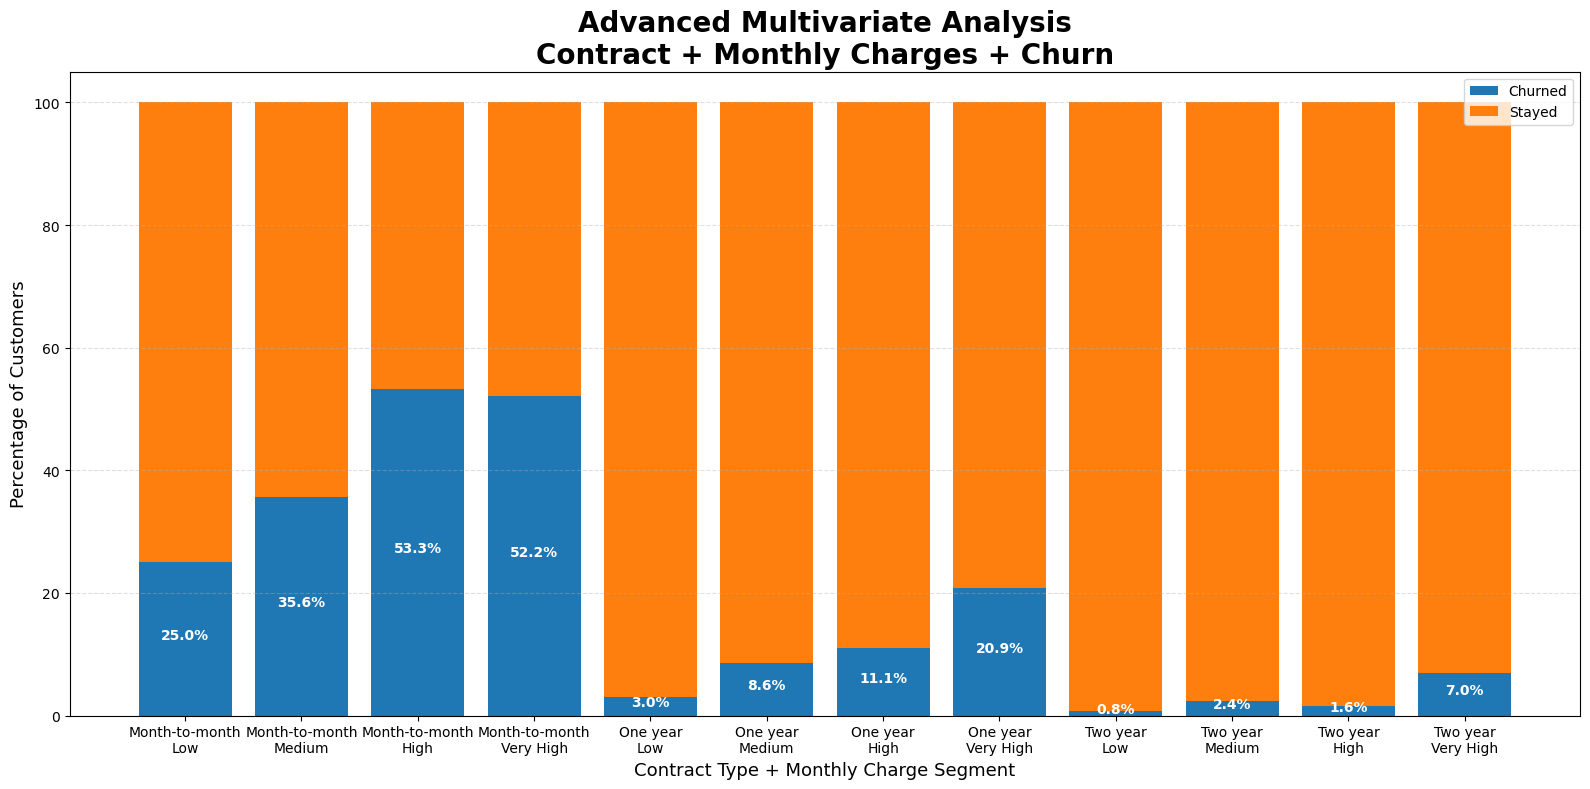

In [1]:
df = pd.read_csv("telcom_churndataset.csv")

# Convert datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill null values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Create Monthly Charge Category
df['ChargeCategory'] = pd.qcut(
    df['MonthlyCharges'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Create Pivot Table
pivot = pd.crosstab(
    [df['Contract'], df['ChargeCategory']],
    df['Churn'],
    normalize='index'
) * 100

# Plot
fig, ax = plt.subplots(figsize=(16,8))

bars_yes = ax.bar(
    np.arange(len(pivot)),
    pivot['Yes'],
    label='Churned'
)

bars_no = ax.bar(
    np.arange(len(pivot)),
    pivot['No'],
    bottom=pivot['Yes'],
    label='Stayed'
)

# Labels
ax.set_title(
    'Advanced Multivariate Analysis\nContract + Monthly Charges + Churn',
    fontsize=20,
    fontweight='bold'
)

ax.set_ylabel('Percentage of Customers', fontsize=13)

ax.set_xlabel('Contract Type + Monthly Charge Segment', fontsize=13)

# X labels
ax.set_xticks(np.arange(len(pivot)))

ax.set_xticklabels(
    [f"{i[0]}\n{i[1]}" for i in pivot.index],
    rotation=0,
    fontsize=10
)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Legend
ax.legend()

# Add Percentage Labels
for i, value in enumerate(pivot['Yes']):
    ax.text(
        i,
        value/2,
        f"{value:.1f}%",
        ha='center',
        color='white',
        fontweight='bold'
    )

plt.tight_layout()

# Show Graph
plt.show()

## **Key Findings**
- Month-to-month customers show the highest churn, especially in High (53.3%) and Very High (52.2%) monthly charges.
- Month-to-month churn is lower in Low (25.0%) and Medium (35.6%) charge groups.
- One-year contracts have much lower churn rates: Low (3.0%), Medium (8.6%), High (11.1%), and Very High (20.9%).
- Two-year contracts show the lowest churn overall: Low (0.8%), Medium (2.4%), High (1.6%), and Very High (7.0%).
- Higher monthly charges combined with month-to-month contracts create the highest churn risk.

# **Comparative Churn Analysis by Service Type**

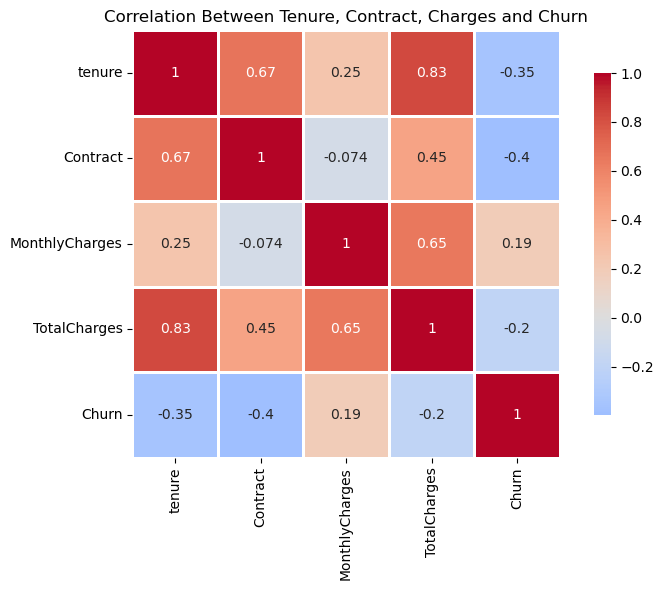

In [38]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("telcom_churndataset.csv")

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Convert Churn into numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert Contract into numeric
df['Contract'] = df['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

# Select required columns
numeric_cols = ['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn']

# Correlation Matrix
corr_matrix = df[numeric_cols].corr()

# Plot Heatmap
fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

ax.set_title('Correlation Between Tenure, Contract, Charges and Churn')

plt.tight_layout()
plt.show()



## **Key correlations with Churn:**
- Tenure: -0.352 (negative – long-term customers churn less)
- Contract: -0.397 (negative – longer contracts reduce churn)
- MonthlyCharges: 0.193 (positive – high monthly charges increase churn)
- TotalCharges: -0.199 (negative – high total spending customers stay longer)

# Telco Customer Churn EDA Report
## Comprehensive Pattern Analysis & Business Insights

---


## Key Business Insights
- Overall churn rate is approximately **26.5%**
- Nearly **75% of churn** is driven by a few high-impact factors:
  - Low customer tenure
  - Month-to-month contracts
  - Manual payment methods
- Strategic retention initiatives can potentially improve retention by **15–20%**

---

#  Tenure vs Churn — Strongest Churn Predictor

## Churn Rate by Tenure Group

| Tenure Group | Churn Rate | Risk Level |
|---|---|---|
| 0–12 Months | 47.7% |  Very High |
| 12–24 Months | 28.7% | High |
| 24–48 Months | 20.4% | Medium |
| 48–72 Months | 9.5% |  Very Low |

##  Key Findings
- Customers are most likely to churn during the **first year**
- Nearly **80% of churn occurs in the early customer lifecycle**
- Average tenure comparison:
  - Non-Churn Customers: **37+ months**
  - Churn Customers: **15 months**

##  Business Interpretation
Customer loyalty increases significantly with longer service duration.  
Early-stage customers are less engaged and more price-sensitive, making onboarding and early customer experience extremely important.

## Recommended Retention Strategies
- Offer welcome discounts during the first 6 months
- Introduce loyalty rewards at the 12-month milestone
- Encourage long-term contracts through upgrade incentives
- Launch proactive engagement campaigns for new customers

---

# 2️ Contract Type — Subscription Lock-in Effect

##  Churn Risk by Contract Type

| Contract Type | Churn Risk |
|---|---|
| Month-to-Month | 65%+ |
| One Year | ~30% |
| Two Year | ~8% |

##  Relationship Between Tenure and Contract Type

| Tenure Range | Dominant Contract Type | Churn Impact |
|---|---|---|
| 0–1 Year | Month-to-Month | High |
| 1–2 Years | One Year | Medium |
| 2–4 Years | Two Year | Low |
| 4–6 Years | Two Year | Very Low |

##  Key Findings
- Month-to-month customers show the highest instability
- Long-term contracts strongly improve customer retention
- Two-year contract users demonstrate the lowest churn behavior


# 3️ Payment Method — Security & Automation Drive Loyalty

##  Churn Rate by Payment Method

| Payment Method | Churn Rate | Observation |
|---|---|---|
| Electronic Check | 45.3% |  Highest |
| Mailed Check | 19.2% | Moderate |
| Bank Transfer (Auto) | 16.7% |  Low |
| Credit Card (Auto) | 15.3% |  Lowest |

##  Key Findings
- Customers using automatic payment methods are significantly less likely to churn
- Electronic check users exhibit the highest churn behavior
- Auto-pay customers demonstrate stronger long-term retention

#

# 4️ Monthly Charges — Price Sensitivity Impact

##  Average Monthly Charges

| Customer Type | Average Monthly Charges |
|---|---|
| Non-Churn Customers | \61.31 |
| Churn Customers | \74.44 |

##  Churn Trend by Price Range

| Monthly Charge Range | Churn Rate |
|---|---|
| \$20–50 | 15% |
| \$50–80 | 28% |
| \$80–120 | 45% |

##  Key Findings
- Higher monthly charges are strongly associated with higher churn
- Customers paying premium prices expect higher service quality
- Fiber Optic users generally fall into higher pricing categories



# 5️ Internet Service Type — Premium Service Risk

##  Churn by Internet Service

| Internet Service | Churn Rate |
|---|---|
| Fiber Optic | 35–45% |
| DSL | ~20% |
| No Internet Service | ~10% |

##  Key Findings
- Fiber Optic customers show the highest churn
- DSL users are comparatively more stable
- Basic service users demonstrate stronger retention



# 6️ Service Add-ons — Customer Engagement Improves Retention

##  Churn by Service Engagement Level

| Engagement Level | Churn Rate |
|---|---|
| High Engagement (Multiple Add-ons) | 12% |
| Low/No Add-ons | 35% |

##  Most Effective Retention Services

| Service | Estimated Churn Reduction |
|---|---|
| Tech Support | -15% |
| Online Security | -12% |
| Device Protection | -10% |

## Key Findings
- Customers using multiple services are significantly more loyal
- Security and support-related services improve customer trust
- Higher engagement creates stronger dependency on the platform


# 7️ Demographic Factors — Secondary Churn Drivers

| Demographic Factor | Observation |
|---|---|
| Senior Citizens | Higher churn (~25%) |
| Paperless Billing | Higher churn tendency |
| Partner/Dependents | Moderate impact |

## Key Findings
- Senior citizens may require additional support and guidance
- Paperless billing users show relatively higher churn patterns
- Family-connected customers tend to remain longer


# 

#  Overall Business Impact

| Metric | Value |
|---|---|
| Overall Churn Rate | ~26.5% |
| Addressable Churn | ~75% |
| Potential Retention Improvement | 15–20% |
| Highest Risk Group | New Customers (<12 months) |

---

#  Final Business Recommendation

The company should prioritize:
1. Early customer retention programs
2. Contract upgrade campaigns
3. Auto-payment adoption
4. Premium customer experience improvement
5. Add-on service bundling

